# PyFue Demo

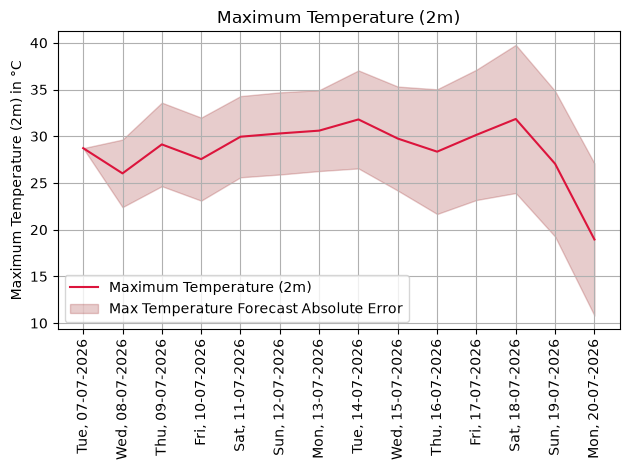

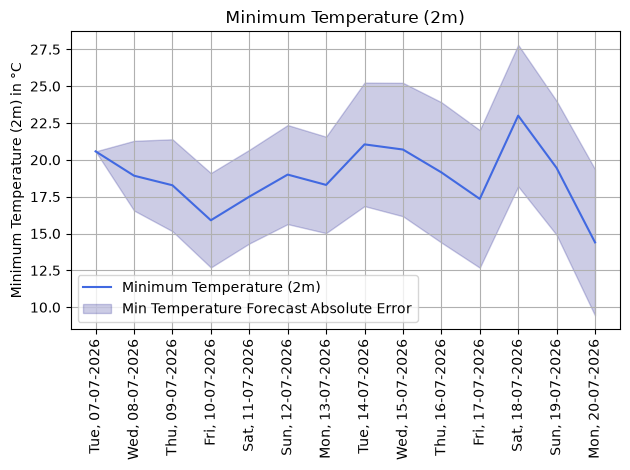

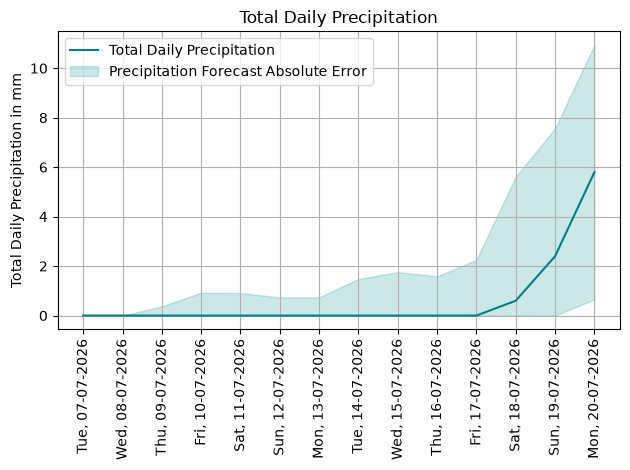

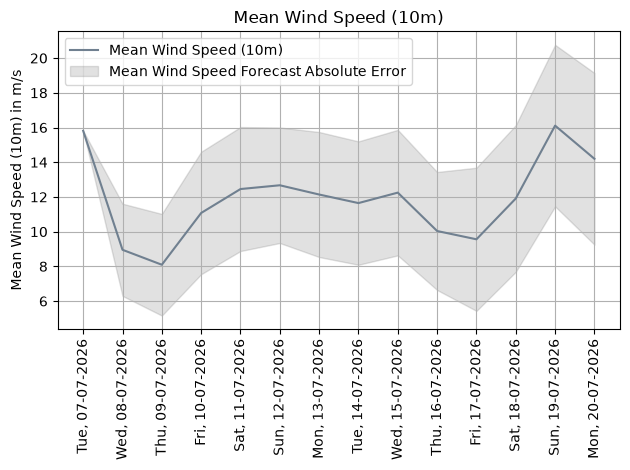

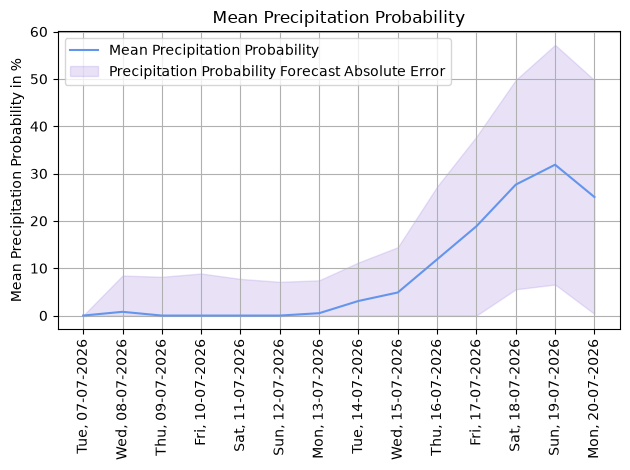

In [1]:
from fue import Config, Data, Forecast
from fue.models import LinearUncertaintyModel

# ==========================================
# 1. Ingest and Pool Multi-City Datasets
# ==========================================
data = Data()
data.read_raw()

all_city_records = []

config = Config()

dataset = data.generate_dataset()
train_df, val_df = data.split_dataset(dataset, val_fraction=0.8)

# ==========================================
# 2. Instantiate Model and Configure Columns
# ==========================================

# Explicitly ensure location markers are part of features so the network adjusts to microclimates
feature_columns = config.default_feature_columns
target_columns = config.default_target_columns

model = LinearUncertaintyModel(config)  # For demonstration, we can also use the linear model
model.fit(train_df, feature_columns, target_columns)
F = Forecast()
F.fetch_forecast(location_name="aachen", forecast_days=14)
F.compute_uncertainties(model)
F.plot(target_variables=target_columns)